# Displacement Orders Data EDA notebook

> In this notebook, we will explore displacement orders to:
>  * uncover patterns.
> * identify trends. 
> * gain insights into their impact on the people of Gaza.

## Import Modules

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [4]:
sns.set_theme(style="whitegrid")

In [5]:
import os

os.chdir("C:/Guest/15-Career/MIT-Emrging Talent Program/ET6-CDSP-group-03-repo")

In [6]:
ocha_data = pd.read_csv(
    "1_datasets/data/clean_datasets/idmc_event_data_for_pse_cleaned.csv"
)
gazamap_data = pd.read_csv(
    "1_datasets/data/clean_datasets/gaza_displacement_cleaned.csv"
)

In [7]:
print("\n Dataset Info")
ocha_data.info()

print("\n Summary Statistics")
display(ocha_data.describe(include="all"))

print("\n Missing Values")
display(ocha_data.isnull().sum())


 Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       60 non-null     float64
 1   country                  60 non-null     object 
 2   iso3                     60 non-null     object 
 3   latitude                 60 non-null     float64
 4   longitude                60 non-null     float64
 5   centroid                 60 non-null     object 
 6   role                     60 non-null     object 
 7   displacement_type        60 non-null     object 
 8   qualifier                60 non-null     object 
 9   figure                   60 non-null     int64  
 10  displacement_date        60 non-null     object 
 11  displacement_start_date  60 non-null     object 
 12  displacement_end_date    60 non-null     object 
 13  year                     60 non-null     int64  
 14  event_id     

,id,country,iso3,latitude,longitude,centroid,role,displacement_type,qualifier,figure,...,source_url,locations_name,locations_coordinates,locations_accuracy,locations_type,displacement_occurred,created_at,description,link,combined_type
count,60.000000,60,60,60.000000,60.000000,60,60,60,60,60.000000,...,60,60,60,60,60,31,60,60,60,60
unique,NaN,1,1,NaN,NaN,25,2,1,3,NaN,...,29,28,25,7,4,1,60,60,29,1
top,NaN,Palestine,PSE,NaN,NaN,"[31.43317, 34.37793]",Recommended figure,Conflict,total,NaN,...,https://demolition.ochaopt.org/login.aspx,"Gaza Strip, Gaza Strip, Palestinian Territories","31.43317, 34.37793",Point,Origin,Displacement without preventive evacuations re...,2025-05-31 10:13:43.357892+00:00,"Palestine: 22,743 displacements, 23 May - 27 M...",https://demolition.ochaopt.org/login.aspx,Conflict
freq,NaN,60,60,NaN,NaN,21,48,60,54,NaN,...,19,10,21,31,56,31,1,1,19,60
mean,181562.150000,NaN,NaN,31.804948,34.904657,NaN,NaN,NaN,NaN,13818.783333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3337.338607,NaN,NaN,0.359691,0.421715,NaN,NaN,NaN,NaN,28146.633299,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,174561.000000,NaN,NaN,31.433170,34.274960,NaN,NaN,NaN,NaN,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,181901.500000,NaN,NaN,31.433170,34.377930,NaN,NaN,NaN,NaN,7.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,182907.500000,NaN,NaN,31.806061,35.070256,NaN,NaN,NaN,NaN,51.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,183509.500000,NaN,NaN,32.094320,35.279794,NaN,NaN,NaN,NaN,15791.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



 Missing Values


id                          0
country                     0
iso3                        0
latitude                    0
longitude                   0
centroid                    0
role                        0
displacement_type           0
qualifier                   0
figure                      0
displacement_date           0
displacement_start_date     0
displacement_end_date       0
year                        0
event_id                    0
event_name                  0
event_start_date            0
event_end_date              0
sources                     0
source_url                  0
locations_name              0
locations_coordinates       0
locations_accuracy          0
locations_type              0
displacement_occurred      29
created_at                  0
description                 0
link                        0
combined_type               0
dtype: int64

### General Trends & Overview

In [8]:
gazamap_data.sort_values(by="date", inplace=True)

### 1. How many displacement orders were issued over time (daily/weekly)?

In [9]:
gazamap_data["date"] = pd.to_datetime(gazamap_data["date"])

In [10]:
gazamap_data["displacement_year"] = gazamap_data["date"].dt.year
gazamap_data["displacement_month"] = gazamap_data["date"].dt.month
gazamap_data["displacement_day"] = gazamap_data["date"].dt.day

In [11]:
dates_groups = (
    gazamap_data.groupby(
        ["displacement_year", "displacement_month", "displacement_day", "date"]
    )
    .agg({"id": "count"})
    .reset_index()
)
dates_groups.rename({"id": "num_orders"}, axis=1, inplace=True)

In [198]:
dates_groups

,displacement_year,displacement_month,displacement_day,date,num_orders
0,2023,10,7,2023-10-07,1
1,2023,10,13,2023-10-13,1
2,2023,11,15,2023-11-15,1
3,2023,12,2,2023-12-02,2
4,2023,12,4,2023-12-04,1
...,...,...,...,...,...
92,2025,6,12,2025-06-12,2
93,2025,6,13,2025-06-13,1
94,2025,6,14,2025-06-14,1
95,2025,6,17,2025-06-17,1


In [12]:
dates = [
    pd.to_datetime(f"{x.month}-{x.year}", format="%m-%Y")
    for x in pd.date_range(
        gazamap_data["date"].min(), gazamap_data["date"].max(), freq="W"
    ).to_list()
]

C:\Users\MSI\AppData\Local\Temp\ipykernel_12152\2666818775.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[1][4] >= 2:
C:\Users\MSI\AppData\Local\Temp\ipykernel_12152\2666818775.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.axvspan(row[1][3],row[1][3] + pd.DateOffset(weeks=1), color='yellow', alpha=0.2)


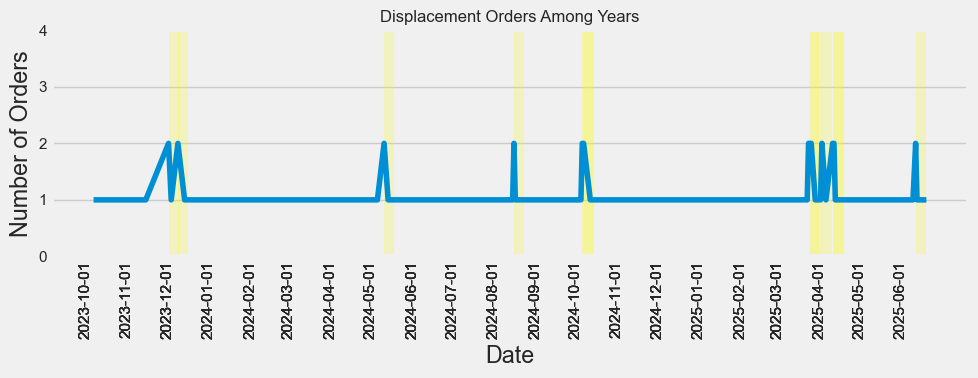

In [14]:
y_max = dates_groups.num_orders.max()
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(figsize=(10, 4))
    for row in dates_groups.iterrows():
        if row[1][4] >= 2:
            plt.axvspan(
                row[1][3], row[1][3] + pd.DateOffset(weeks=1), color="yellow", alpha=0.2
            )

    sns.lineplot(data=dates_groups, x="date", y="num_orders", markersize=3, ax=ax)
    plt.title("Displacement Orders Among Years", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Number of Orders")
    plt.yticks(range(0, int(y_max) + 3))
    plt.xticks(dates, rotation="vertical")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_12152\1247805981.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\MSI\AppData\Local\Temp\ipykernel_12152\1247805981.py:7: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\MSI\AppData\Local\Temp\ipykernel_12152\1247805981.py:8: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



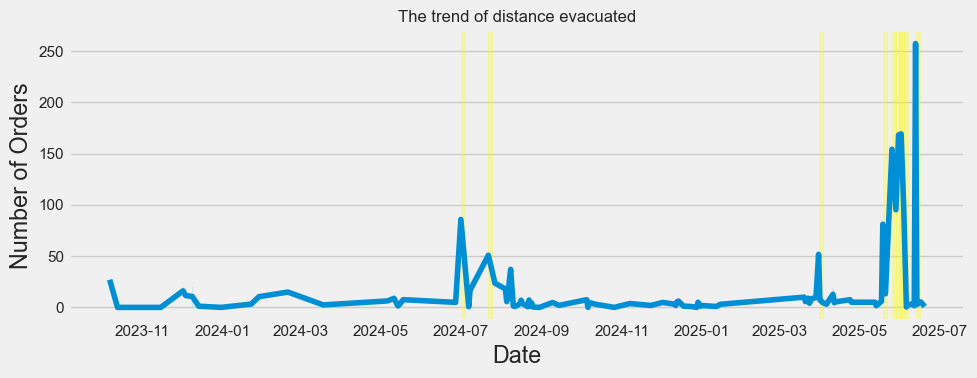

In [90]:
y_max = gazamap_data.area_sq_km_displacement.max()
most_displacement_areas = []
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(nrows=1, figsize=(10, 4))
    for row in gazamap_data.iterrows():
        if row[1][9] >= 50:
            plt.axvspan(
                row[1][1], row[1][1] + pd.DateOffset(days=3), color="yellow", alpha=0.3
            )
            most_displacement_areas.append(row[1][1])

    sns.lineplot(data=gazamap_data, x="date", y="area_sq_km_displacement", ax=ax)
    plt.title("The trend of distance evacuated", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Number of Orders")
    # plt.yticks(range(0, int(y_max) + 3))
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

In [100]:
gazamap_data.head()

,id,date,source,link,map_idf,map_full,map_zoom,displacement_blocks,labeled_safe_blocks,area_sq_km_displacement,area_sq_km_labeled_safe,displacement_year,displacement_month,displacement_day
108,16,2023-10-07,https://x.com/avichayadraee/status/17107769972...,https://gazamaps.com/displacement/16,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,"10, 11, 12, 569, 570, 571, 574, 578, 579, 580,...",NaN,27.00,0.0,2023,10,7
107,102,2023-10-13,https://x.com/AvichayAdraee/status/17128464937...,https://gazamaps.com/displacement/102,https://gazamaps.com/storage/displacement-maps...,NaN,NaN,NaN,NaN,0.00,0.0,2023,10,13
106,105,2023-11-15,https://x.com/AvichayAdraee/status/17246987877...,https://gazamaps.com/displacement/105,https://gazamaps.com/storage/displacement-maps...,NaN,NaN,NaN,NaN,0.00,0.0,2023,11,15
105,42,2023-12-02,https://x.com/AvichayAdraee/status/17308498684...,https://gazamaps.com/displacement/42,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,"699, 713, 714, 715, 718, 719, 723, 754, 755, 7...",NaN,11.74,0.0,2023,12,2
104,18,2023-12-02,https://x.com/AvichayAdraee/status/17308498684...,https://gazamaps.com/displacement/18,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,https://gazamaps.com/storage/displacement-maps...,"578, 602, 604, 605, 606, 607, 608, 609, 617, 6...",NaN,20.63,0.0,2023,12,2


Zoom in the most evacuated area months

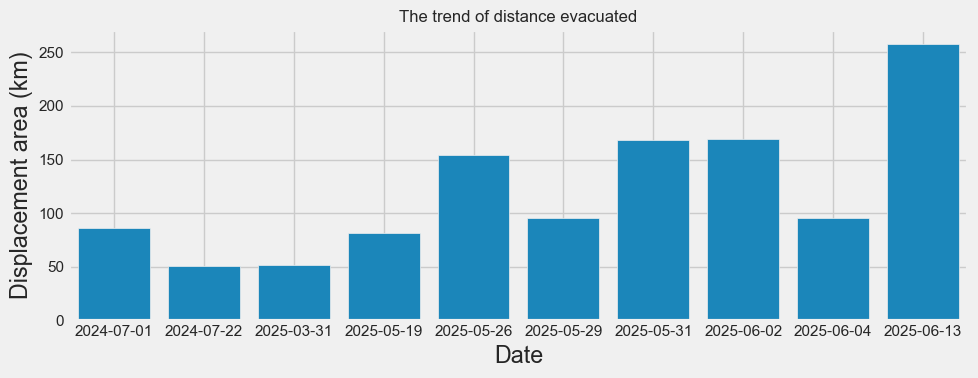

In [99]:
most_displaced_df = gazamap_data[gazamap_data["date"].isin(most_displacement_areas)]
with plt.style.context("fivethirtyeight"):
    fig, ax = plt.subplots(nrows=1, figsize=(10, 4))
    sns.barplot(data=most_displaced_df, x="date", y="area_sq_km_displacement", ax=ax)
    plt.title("The trend of distance evacuated", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Displacement area (km)")
    # plt.yticks(range(0, int(y_max) + 3))
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

### 2.What is the geographical distribution of displacement orders?

In [51]:
gaza_data = ocha_data[ocha_data["locations_name"].str.contains("Gaza")]

In [55]:
import plotly.express as px

fig = px.scatter_mapbox(
    gaza_data, lat="latitude", lon="longitude", color="figure", zoom=10, height=500
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [263]:
gaza_data.columns

Index(['id', 'country', 'iso3', 'latitude', 'longitude', 'centroid', 'role',
       'displacement_type', 'qualifier', 'figure', 'displacement_date',
       'displacement_start_date', 'displacement_end_date', 'year', 'event_id',
       'event_name', 'event_start_date', 'event_end_date', 'sources',
       'source_url', 'locations_name', 'locations_coordinates',
       'locations_accuracy', 'locations_type', 'displacement_occurred',
       'created_at', 'description', 'link', 'combined_type'],
      dtype='object')

## Population Impact

### 1. How many people were affected per displacement order?

In [56]:
gaza_data.qualifier

0                     total
1                     total
2                     total
3                     total
4                     total
5                     total
6                     total
7                     total
8                     total
9                     total
10                    total
11                    total
12                    total
14                    total
16                    total
18                    total
19                    total
20                    total
21                    total
22                    total
23    more than or equal to
24                    total
Name: qualifier, dtype: object

In [31]:
gaza_data.displacement_date.max()

'2025-05-27'

In [34]:
gazamap_data[
    (gazamap_data["date"] >= "2025-03-18") & (gazamap_data["date"] <= "2025-05-27")
].shape

(27, 14)

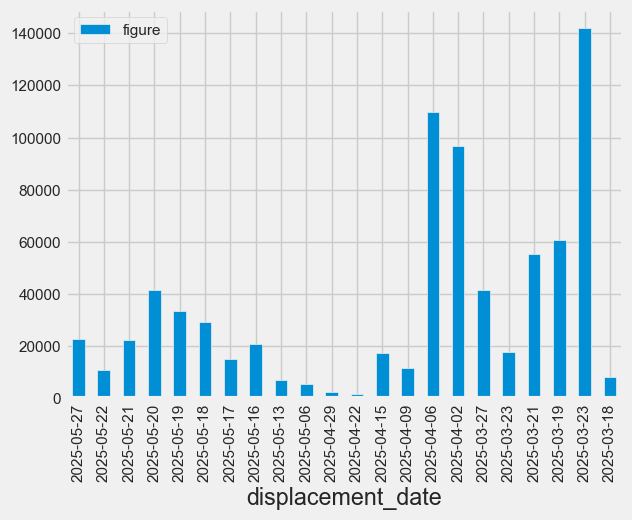

In [24]:
with plt.style.context("fivethirtyeight"):
    gaza_data.plot(kind="bar", x="displacement_date", y="figure")
    plt.show()